In [39]:
import numpy as np                           
import pandas as pd                                 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline           
from sklearn.compose import ColumnTransformer     
from sklearn.preprocessing import StandardScaler, RobustScaler      
from sklearn.preprocessing import OneHotEncoder       
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, learning_curve

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [27]:
data = pd.read_csv("..\\data\\train_clean.csv")
data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.0,58.0,1.75,MARUTI,WAGON R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.0,126.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION
2,Chennai,2011,46000,Petrol,Manual,First,18.0,88.0,4.50,HONDA,JAZZ V
3,Chennai,2012,87000,Diesel,Manual,First,20.0,88.0,6.00,MARUTI,ERTIGA VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.0,140.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC


In [28]:
X = data.drop(columns=["Price"])
y = data["Price"] 

In [29]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [15]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.2,                                   
    random_state=42                                   
)

In [16]:
linreg_model1 = Pipeline(steps=[
    ("preprocess", preprocess),                        # Preprocess (fit on train only)
    ("model", LinearRegression())                      # Linear regression model
])

linreg_model1.fit(X_train, y_train)                     # Fit pipeline on training set only
print("Linear Regression trained.")

Linear Regression trained.


In [24]:
def evaluate_regression(model, X_test, y_test, name="model"):
    """
    Evaluate a regression model on the test set using:
    - MAE
    - RMSE
    - R²
    Also plots Actual vs Predicted.
    """
    preds = model.predict(X_test)                     

    mae = mean_absolute_error(y_test, preds)   
    mse = mean_squared_error(y_test, preds)       
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)                      

    print(f"\n--- {name} ---")                        
    print(f"MAE : {mae:.4f}")  
    print(f"MSE: {mse:.4f}")                        
    print(f"RMSE: {rmse:.4f}")                        
    print(f"R^2 : {r2:.4f}")                          

    plt.figure()                                      
    plt.scatter(y_test, preds, s=8)                   
    plt.title(f"{name}: Actual vs Predicted")         
    plt.xlabel("Actual")                              
    plt.ylabel("Predicted")                           
    plt.show()                                        

    return mae, mse, rmse, r2 


--- Linear Regression ---
MAE : 2.1541
MSE: 22.8982
RMSE: 4.7852
R^2 : 0.8142


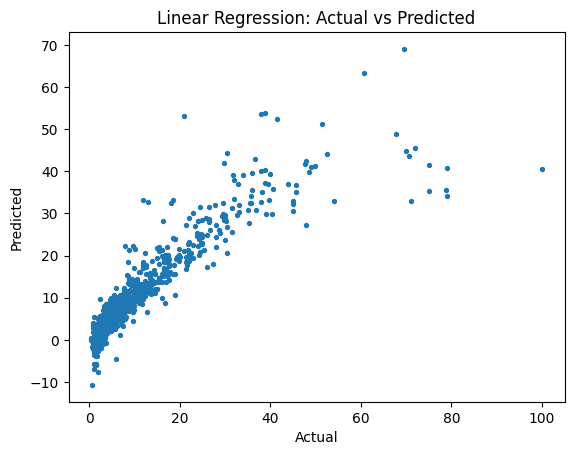

In [25]:
linreg_scores = evaluate_regression(                   # Evaluate baseline model
    linreg_model1,                                      # Pipeline
    X_test,                                            # Test features
    y_test,                                            # Test target
    "Linear Regression"                                # Name
)

In [51]:
linreg_model = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", LinearRegression())                      
])

In [ ]:
taille_train, scrore_train, score_test = learning_curve(linreg_model, X, y, cv=10, scoring='r2', random_state=42)

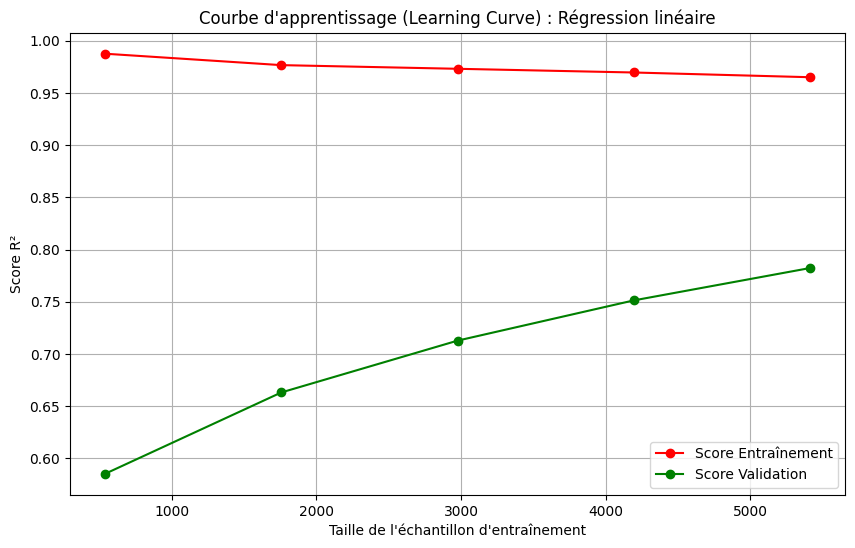

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculer les moyennes des scores (car il y a plusieurs résultats par test via cv=5)
train_scores_mean = np.mean(scrore_train, axis=1)
test_scores_mean = np.mean(score_test, axis=1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))

# Tracé de la courbe d'entraînement (Rouge)
plt.plot(taille_train, train_scores_mean, 'o-', color="r", label="Score Entraînement")

# Tracé de la courbe de test/validation (Vert)
plt.plot(taille_train, test_scores_mean, 'o-', color="g", label="Score Validation")

# 3. Habillage du graphe
plt.title("Courbe d'apprentissage (Learning Curve) : Régression linéaire")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc="best")
plt.grid(True)

plt.show()

In [46]:
lasso_model = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", Lasso())                      
])

In [ ]:
taille_train, scrore_train, score_test = learning_curve(lasso_model, X, y, cv=10, scoring='r2', random_state=42)

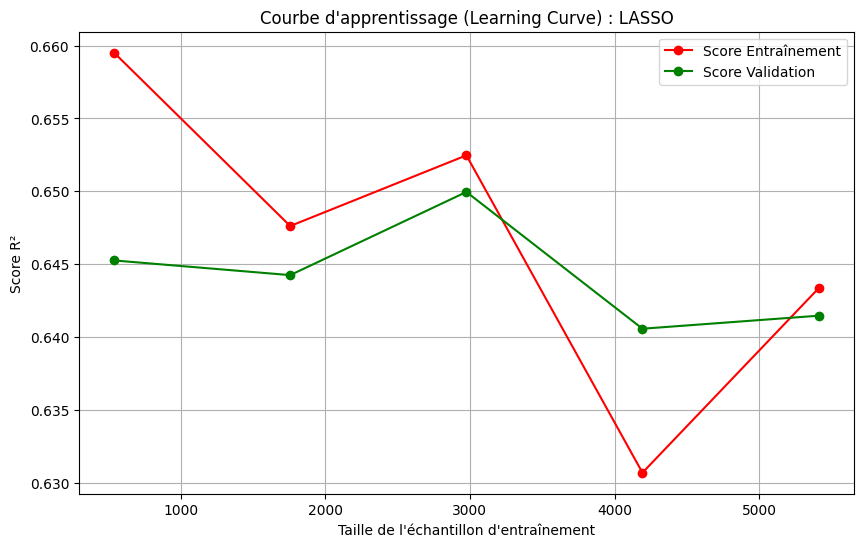

In [48]:

# 1. Calculer les moyennes des scores (car il y a plusieurs résultats par test via cv=5)
train_scores_mean = np.mean(scrore_train, axis=1)
test_scores_mean = np.mean(score_test, axis=1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))

# Tracé de la courbe d'entraînement (Rouge)
plt.plot(taille_train, train_scores_mean, 'o-', color="r", label="Score Entraînement")

# Tracé de la courbe de test/validation (Vert)
plt.plot(taille_train, test_scores_mean, 'o-', color="g", label="Score Validation")

# 3. Habillage du graphe
plt.title("Courbe d'apprentissage (Learning Curve) : LASSO")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc="best")
plt.grid(True)

plt.show()

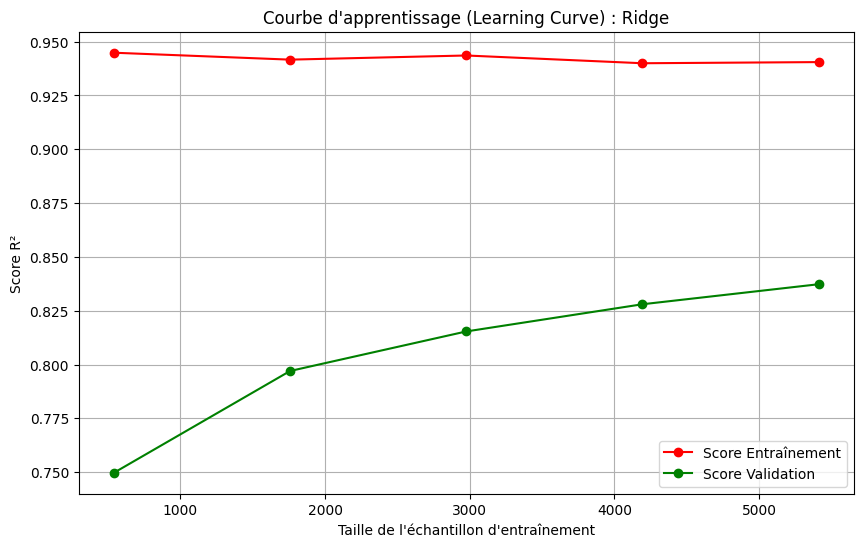

In [ ]:
ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", Ridge())                      
])

taille_train, scrore_train, score_test = learning_curve(ridge_model, X, y, cv=10, scoring='r2', random_state=42)

# 1. Calculer les moyennes des scores (car il y a plusieurs résultats par test via cv=5)
train_scores_mean = np.mean(scrore_train, axis=1)
test_scores_mean = np.mean(score_test, axis=1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))

# Tracé de la courbe d'entraînement (Rouge)
plt.plot(taille_train, train_scores_mean, 'o-', color="r", label="Score Entraînement")

# Tracé de la courbe de test/validation (Vert)
plt.plot(taille_train, test_scores_mean, 'o-', color="g", label="Score Validation")

# 3. Habillage du graphe
plt.title("Courbe d'apprentissage (Learning Curve) : Ridge")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc="best")
plt.grid(True)

plt.show()

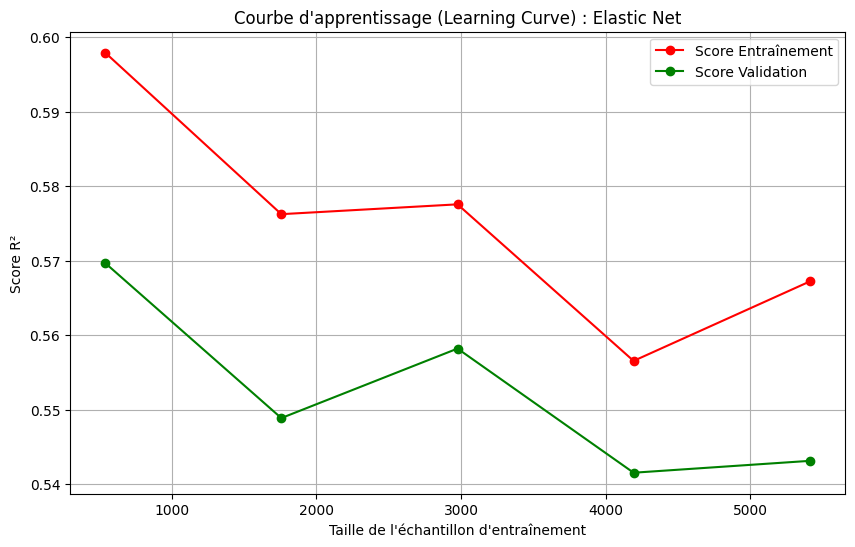

In [ ]:
elsatic_model = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", ElasticNet())                      
])

taille_train, scrore_train, score_test = learning_curve(elsatic_model, X, y, cv=10, scoring='r2', random_state=42)

# 1. Calculer les moyennes des scores (car il y a plusieurs résultats par test via cv=5)
train_scores_mean = np.mean(scrore_train, axis=1)
test_scores_mean = np.mean(score_test, axis=1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))

# Tracé de la courbe d'entraînement (Rouge)
plt.plot(taille_train, train_scores_mean, 'o-', color="r", label="Score Entraînement")

# Tracé de la courbe de test/validation (Vert)
plt.plot(taille_train, test_scores_mean, 'o-', color="g", label="Score Validation")

# 3. Habillage du graphe
plt.title("Courbe d'apprentissage (Learning Curve) : Elastic Net")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc="best")
plt.grid(True)

plt.show()